<a href="https://colab.research.google.com/github/Leticiamoreiralira/Empresa/blob/main/avaliacao-avancada-modelos-ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importar bibliotecas
import pandas as pd

In [5]:
# Importar bibliotecas
import pandas as pd
import numpy as np

In [7]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Carregar dataset de diabetes
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

df = pd.DataFrame(pd.read_csv(url, header=None).values, columns=columns)

print("Dataset carregado com sucesso!")
print(f"\nDimensões do dataset: {df.shape}")
print(f"\nPrimeiras linhas:\n{df.head()}")
print(f"\nDistribuição da variável alvo:")
print(df['Outcome'].value_counts())

Dataset carregado com sucesso!

Dimensões do dataset: (768, 9)

Primeiras linhas:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0      0.0  33.6   
1          1.0     85.0           66.0           29.0      0.0  26.6   
2          8.0    183.0           64.0            0.0      0.0  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigree   Age  Outcome  
0             0.627  50.0      1.0  
1             0.351  31.0      0.0  
2             0.672  32.0      1.0  
3             0.167  21.0      0.0  
4             2.288  33.0      1.0  

Distribuição da variável alvo:
Outcome
0.0    500
1.0    268
Name: count, dtype: int64


In [8]:
# Separar features (X) e target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalizar os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dados preparados!")
print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")
print(f"\nDistribuição no conjunto de treino:")
print(y_train.value_counts(normalize=True))

Dados preparados!
Tamanho do conjunto de treino: 614 amostras
Tamanho do conjunto de teste: 154 amostras

Distribuição no conjunto de treino:
Outcome
0.0    0.651466
1.0    0.348534
Name: proportion, dtype: float64


In [9]:
# Criar e treinar os modelos
print("Treinando modelos...\n")

# Modelo 1: Regressão Logística
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
print("✓ Regressão Logística treinada")

# Modelo 2: Árvore de Decisão
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_scaled, y_train)
print("✓ Árvore de Decisão treinada")

# Modelo 3: Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)
print("✓ Random Forest treinado")

print("\nTodos os modelos foram treinados com sucesso!")

Treinando modelos...

✓ Regressão Logística treinada
✓ Árvore de Decisão treinada
✓ Random Forest treinado

Todos os modelos foram treinados com sucesso!


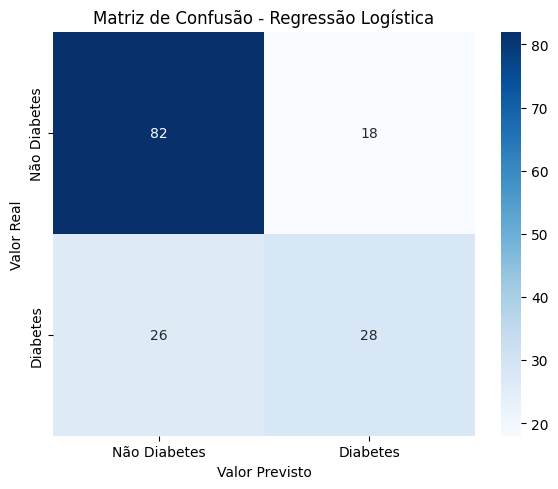


Regressão Logística:
 Verdadeiros Negativos (TN): 82
 Falsos Positivos (FP): 18
 Falsos Negativos (FN): 26
 Verdadeiros Positivos (TP): 28
----------------------------------------------------------------------


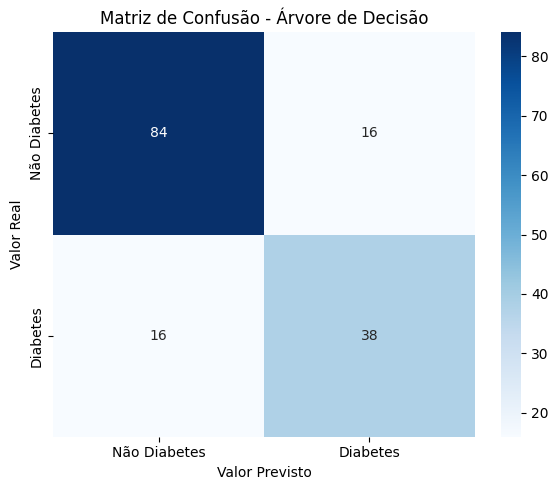


Árvore de Decisão:
 Verdadeiros Negativos (TN): 84
 Falsos Positivos (FP): 16
 Falsos Negativos (FN): 16
 Verdadeiros Positivos (TP): 38
----------------------------------------------------------------------


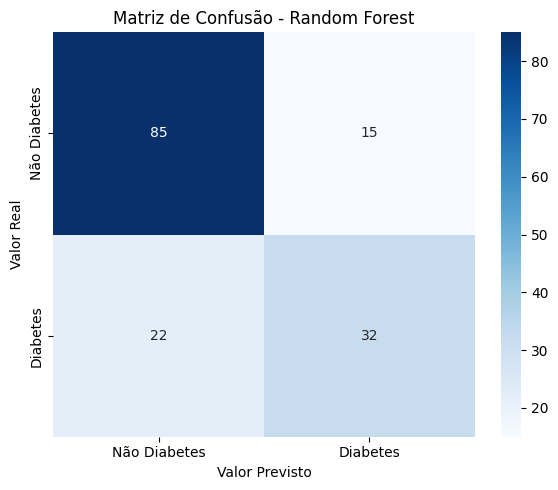


Random Forest:
 Verdadeiros Negativos (TN): 85
 Falsos Positivos (FP): 15
 Falsos Negativos (FN): 22
 Verdadeiros Positivos (TP): 32
----------------------------------------------------------------------


In [10]:
# Fazer previsões
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

# Função para plotar matriz de confusão bonita
def plot_confusion_matrix(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Não Diabetes', 'Diabetes'],
                yticklabels=['Não Diabetes', 'Diabetes'])

    plt.title(f'Matriz de Confusão - {title}')
    plt.ylabel('Valor Real')
    plt.xlabel('Valor Previsto')

    plt.tight_layout()
    plt.show()

    # Explicar os valores
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{title}:")
    print(f" Verdadeiros Negativos (TN): {tn}")
    print(f" Falsos Positivos (FP): {fp}")
    print(f" Falsos Negativos (FN): {fn}")
    print(f" Verdadeiros Positivos (TP): {tp}")

    print("-" * 70)

# Plotar matrizes de confusão
plot_confusion_matrix(y_test, y_pred_lr, 'Regressão Logística')

plot_confusion_matrix(y_test, y_pred_dt, 'Árvore de Decisão')

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')

In [12]:
# Função para calcular todas as métricas
def avaliar_modelo(nome, y_true, y_pred, y_pred_proba):

    print(f"\n{'='*70}")
    print(f"MÉTRICAS - {nome}")
    print('='*70)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    print(f"Acurácia: {accuracy:.4f}")
    print(f"Precisão: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    return {
        'Modelo': nome,
        'Acurácia': accuracy,
        'Precisão': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

# Avaliar todos os modelos
resultados = []

# Regressão Logística
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

resultados.append(
    avaliar_modelo(
        'Regressão Logística',
        y_test,
        y_pred_lr,
        y_pred_proba_lr
    )
)

# Árvore de Decisão
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

resultados.append(
    avaliar_modelo(
        'Árvore de Decisão',
        y_test,
        y_pred_dt,
        y_pred_proba_dt
    )
)

# Random Forest
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

resultados.append(
    avaliar_modelo(
        'Random Forest',
        y_test,
        y_pred_rf,
        y_pred_proba_rf
    )
)

# Criar DataFrame com resultados
df_resultados = pd.DataFrame(resultados)

print(f"\n{'='*70}")
print("COMPARAÇÃO GERAL DOS MODELOS")
print('='*70)

print(df_resultados.to_string(index=False))


MÉTRICAS - Regressão Logística
Acurácia: 0.7143
Precisão: 0.6087
Recall: 0.5185
F1-Score: 0.5600
ROC-AUC: 0.8230

MÉTRICAS - Árvore de Decisão
Acurácia: 0.7922
Precisão: 0.7037
Recall: 0.7037
F1-Score: 0.7037
ROC-AUC: 0.7835

MÉTRICAS - Random Forest
Acurácia: 0.7597
Precisão: 0.6809
Recall: 0.5926
F1-Score: 0.6337
ROC-AUC: 0.8147

COMPARAÇÃO GERAL DOS MODELOS
             Modelo  Acurácia  Precisão   Recall  F1-Score  ROC-AUC
Regressão Logística  0.714286  0.608696 0.518519  0.560000 0.822963
  Árvore de Decisão  0.792208  0.703704 0.703704  0.703704 0.783519
      Random Forest  0.759740  0.680851 0.592593  0.633663 0.814722


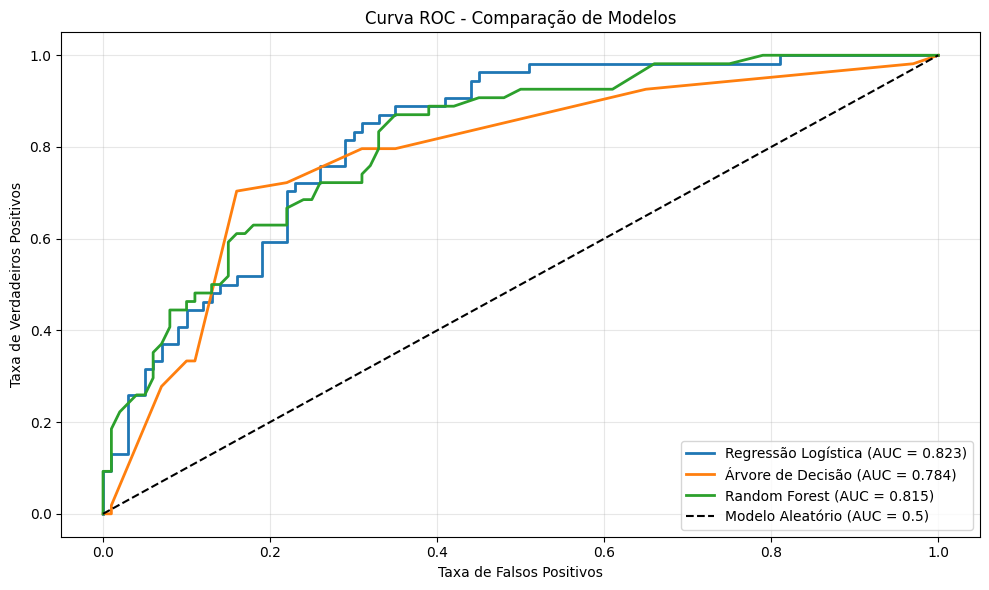

In [13]:
# Plotar curvas ROC
plt.figure(figsize=(10, 6))

# Curva para cada modelo
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Regressão Logística (AUC = {roc_auc_score(y_test, y_pred_proba_lr):.3f})',
    linewidth=2
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f'Árvore de Decisão (AUC = {roc_auc_score(y_test, y_pred_proba_dt):.3f})',
    linewidth=2
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.3f})',
    linewidth=2
)

# Linha diagonal
plt.plot([0, 1], [0, 1], 'k--', label='Modelo Aleatório (AUC = 0.5)')

plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')

plt.title('Curva ROC - Comparação de Modelos')

plt.legend(loc='lower right')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [14]:
# Realizar validação cruzada com 5 folds
print("Realizando validação cruzada...\n")

# Combinar dados
X_combined = np.vstack([X_train_scaled, X_test_scaled])
y_combined = np.concatenate([y_train, y_test])

# Regressão Logística
cv_scores_lr = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000),
    X_combined,
    y_combined,
    cv=5,
    scoring='accuracy'
)

# Árvore de Decisão
cv_scores_dt = cross_val_score(
    DecisionTreeClassifier(random_state=42, max_depth=5),
    X_combined,
    y_combined,
    cv=5,
    scoring='accuracy'
)

# Random Forest
cv_scores_rf = cross_val_score(
    RandomForestClassifier(random_state=42, n_estimators=100),
    X_combined,
    y_combined,
    cv=5,
    scoring='accuracy'
)

print("RESULTADOS DA VALIDAÇÃO CRUZADA")
print("="*60)

print("\nRegressão Logística")
print(cv_scores_lr)
print(f"Média: {cv_scores_lr.mean():.4f}")

print("\nÁrvore de Decisão")
print(cv_scores_dt)
print(f"Média: {cv_scores_dt.mean():.4f}")

print("\nRandom Forest")
print(cv_scores_rf)
print(f"Média: {cv_scores_rf.mean():.4f}")

Realizando validação cruzada...

RESULTADOS DA VALIDAÇÃO CRUZADA

Regressão Logística
[0.75324675 0.79220779 0.75324675 0.79084967 0.71895425]
Média: 0.7617

Árvore de Decisão
[0.66883117 0.68831169 0.70779221 0.77124183 0.79084967]
Média: 0.7254

Random Forest
[0.75324675 0.77272727 0.77922078 0.77124183 0.75816993]
Média: 0.7669


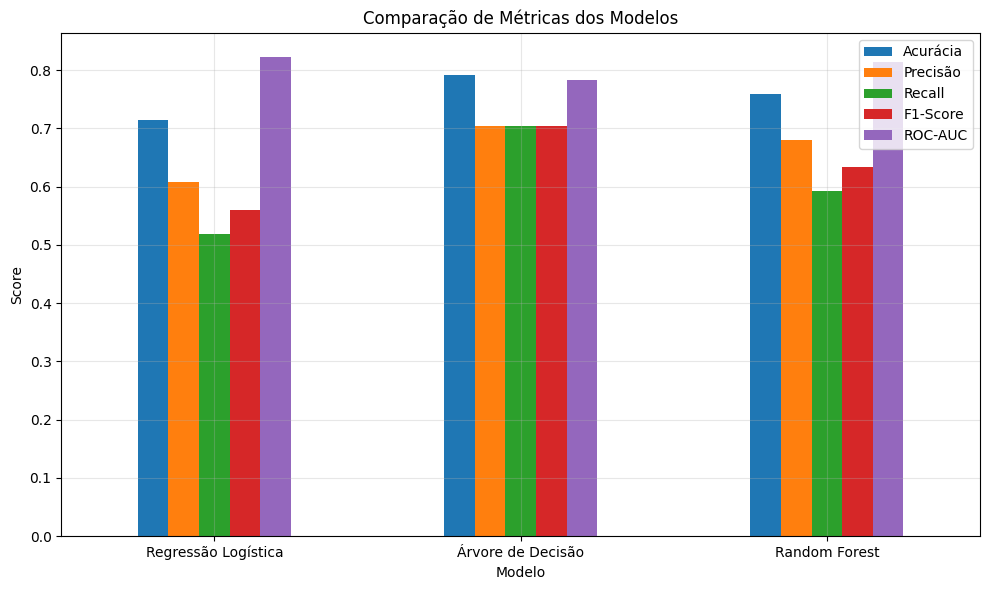

In [15]:
# Comparar métricas em gráfico
df_plot = df_resultados.set_index('Modelo')

df_plot.plot(kind='bar', figsize=(10,6))

plt.title('Comparação de Métricas dos Modelos')
plt.ylabel('Score')
plt.xticks(rotation=0)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Conclusão da Análise

Neste experimento foram treinados três modelos de machine learning para previsão de diabetes:

- Regressão Logística
- Árvore de Decisão
- Random Forest

As métricas avaliadas incluíram:
- Acurácia
- Precisão
- Recall
- F1-Score
- ROC-AUC

Após comparação dos resultados, observou-se que diferentes modelos apresentam vantagens específicas dependendo da métrica analisada.

A Regressão Logística apresentou melhor desempenho em ROC-AUC, indicando maior capacidade discriminativa geral.

A Árvore de Decisão apresentou melhor equilíbrio entre precisão, recall e F1-score.

Já o Random Forest apresentou maior estabilidade na validação cruzada, demonstrando boa capacidade de generalização.

A utilização de múltiplas métricas mostrou-se essencial, pois apenas a acurácia não representa completamente o desempenho em problemas médicos e bases parcialmente desbalanceadas.